# Importing libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from scipy import stats
import xgboost as xgb
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
color_pal = sns.color_palette()

In [2]:
df = pd.read_csv("PJME_hourly.csv")

In [3]:
duplicates = df.duplicated().sum()
print(f"Duplicated records found: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")


df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime")

df = df.sort_index()

Duplicated records found: 0


In [4]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [5]:
df.tail()

,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


> This dataset contains measurements from 2002 to 2018.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


> **PJME_MW** stands for: Hourly electricity consumption of the eastern region of the PJM U.S. power grid, measured in megawatts (MW).

# Outlier detection

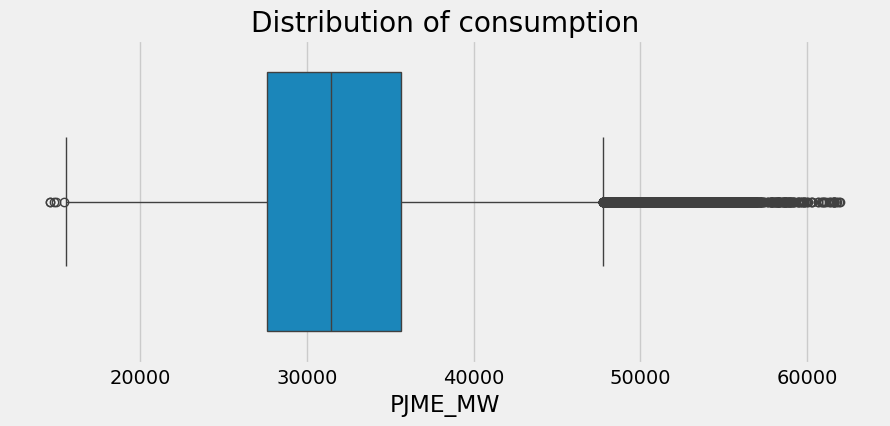

In [7]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['PJME_MW'])
plt.title('Distribution of consumption')
plt.show()

Total records in dataset: 145366
Number of outliers detected (Z-score > 4.0): 93
Percentage of outliers: 0.06%


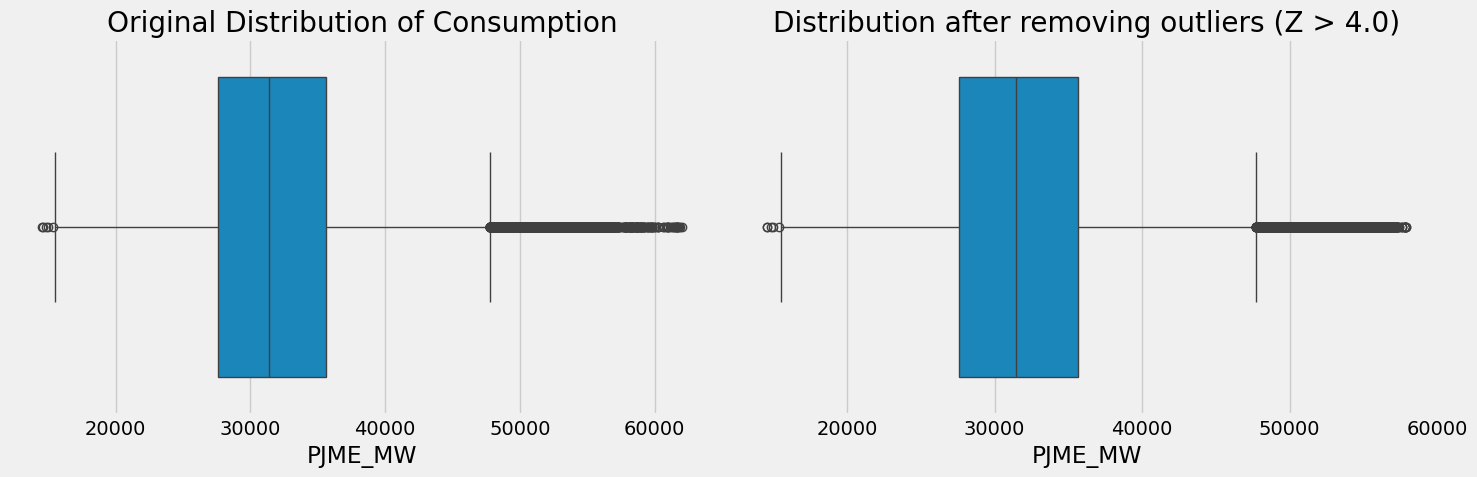

Interpolating removed outlier values...


In [8]:
Z_THRESHOLD = 4.0

df['z_score'] = np.abs(stats.zscore(df['PJME_MW']))

outliers = df[df['z_score'] > Z_THRESHOLD]
print(f"Total records in dataset: {len(df)}")
print(f"Number of outliers detected (Z-score > {Z_THRESHOLD}): {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers) / len(df)) * 100:.2f}%")


# Visualize the data with and without outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['PJME_MW'], ax=axes[0])
axes[0].set_title('Original Distribution of Consumption')

# Replace outliers with NaN
df.loc[df['z_score'] > Z_THRESHOLD, 'PJME_MW'] = np.nan

# Distribution after removing outliers (temporarily ignoring NaNs for the plot)
sns.boxplot(x=df['PJME_MW'].dropna(), ax=axes[1])
axes[1].set_title(f'Distribution after removing outliers (Z > {Z_THRESHOLD})')

plt.tight_layout()
plt.show()

# Interpolate the missing values (previously outliers) using interpolation
print("Interpolating removed outlier values...")
df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

# Drop the temporary Z-score column as it is no longer needed
df = df.drop(columns=['z_score'])

# Exploratory Data Analysis (EDA)

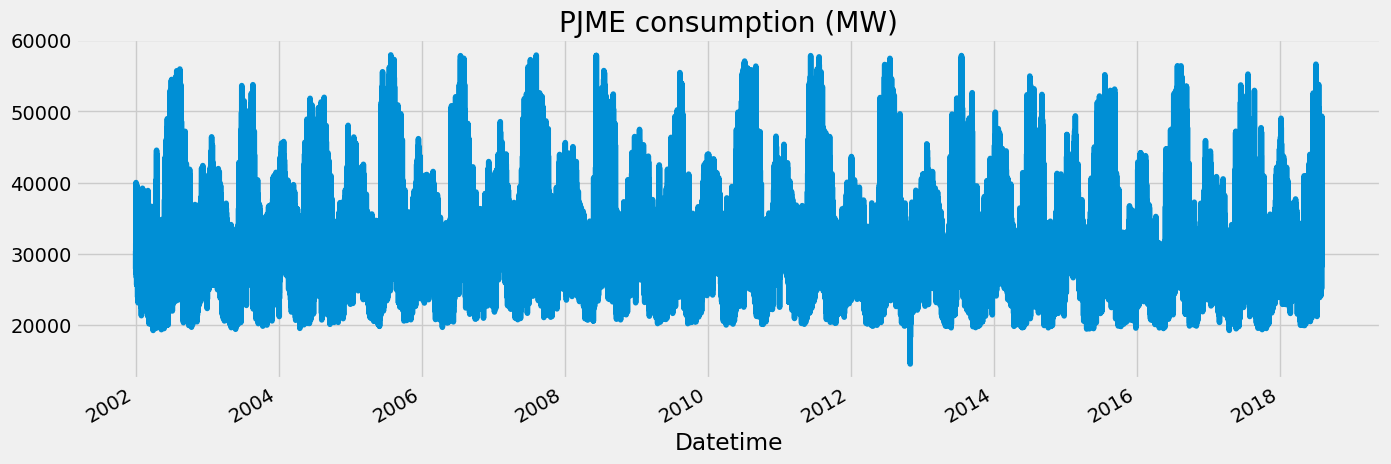

In [9]:
df['PJME_MW'].plot(figsize=(15,5), color=color_pal[0], title="PJME consumption (MW)")
plt.show()

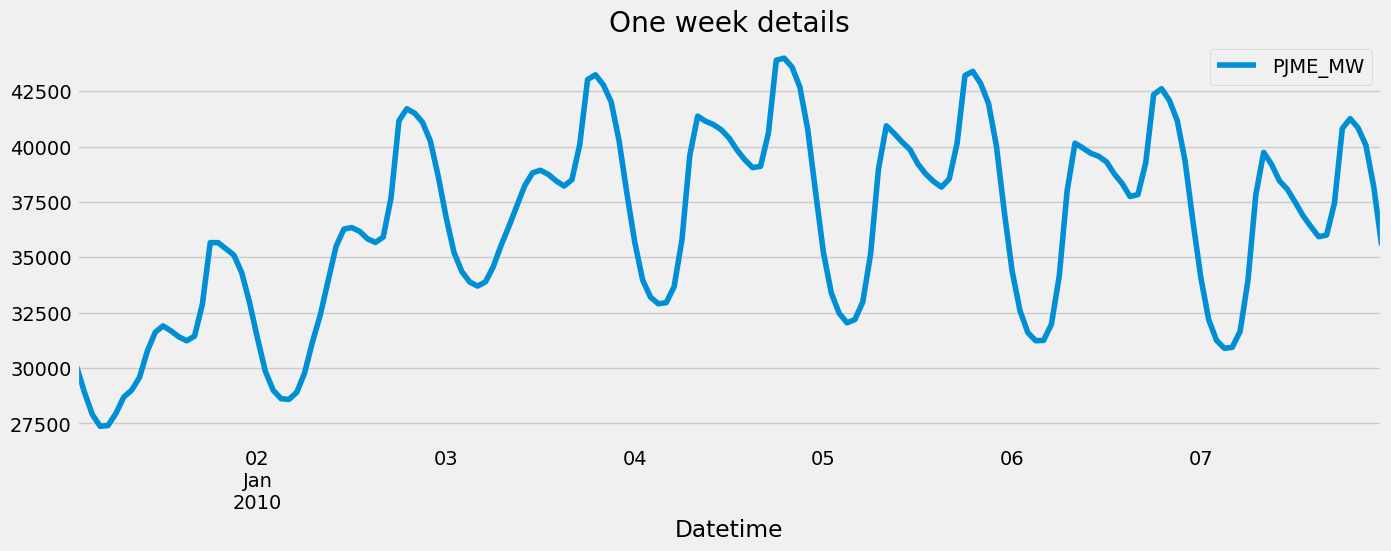

In [10]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')].plot(figsize=(15,5))
plt.title('One week details')
plt.show()

In [11]:
def add_features(dataset):
    df_temp = dataset.copy()
    df_temp['Hour'] = df_temp.index.hour
    df_temp['DayOfWeek'] = df_temp.index.dayofweek
    df_temp['Month'] = df_temp.index.month
    df_temp['Year'] = df_temp.index.year
    df_temp['Quarter'] = df_temp.index.quarter
    df_temp['DayOfYear'] = df_temp.index.dayofyear
    return df_temp

df = add_features(df)

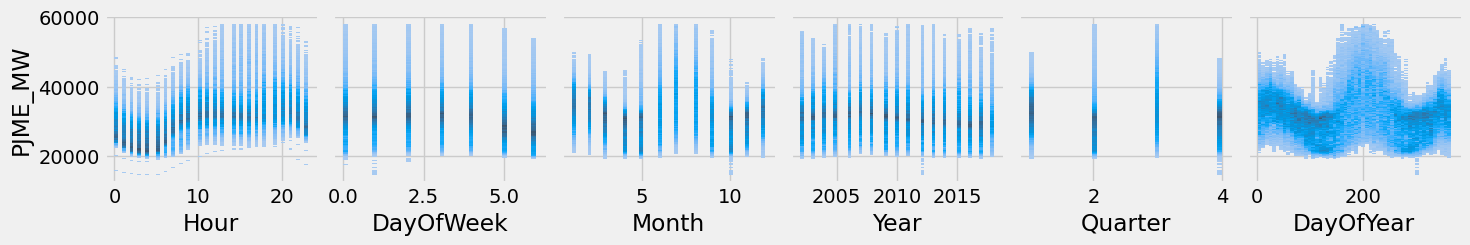

In [12]:
sns.pairplot(data=df, x_vars=['Hour', 'DayOfWeek', 'Month', 'Year', 'Quarter', 'DayOfYear'], y_vars='PJME_MW', kind='hist')
plt.show()

`Daily Seasonality (Hour):` Energy demand follows a distinct intra-day curve. Consumption hits its lowest point during the early morning hours (around 4:00 AM) and peaks in the late afternoon to early evening (16:00 - 19:00) when both commercial and residential usage overlap.

`Weekly Seasonality (DayOfWeek):` There is a clear distinction between weekdays (0-4) and weekends (5-6). Weekend consumption drops significantly due to the reduction in industrial and corporate business activities.

`Yearly Seasonality (Month, Quarter, DayOfYear):` The data exhibits a distinct bi-modal annual pattern. The highest consumption peaks occur during the summer months (July and August in Q3), heavily driven by air conditioning demand. A secondary, slightly lower peak occurs in the winter (January and February in Q1) due to heating requirements. Spring and autumn represent the low-demand "valleys."

`Long-Term Trend (Year):` The overall yearly consumption remains relatively stable over the observed decade, without extreme long-term upward or downward macro trends.

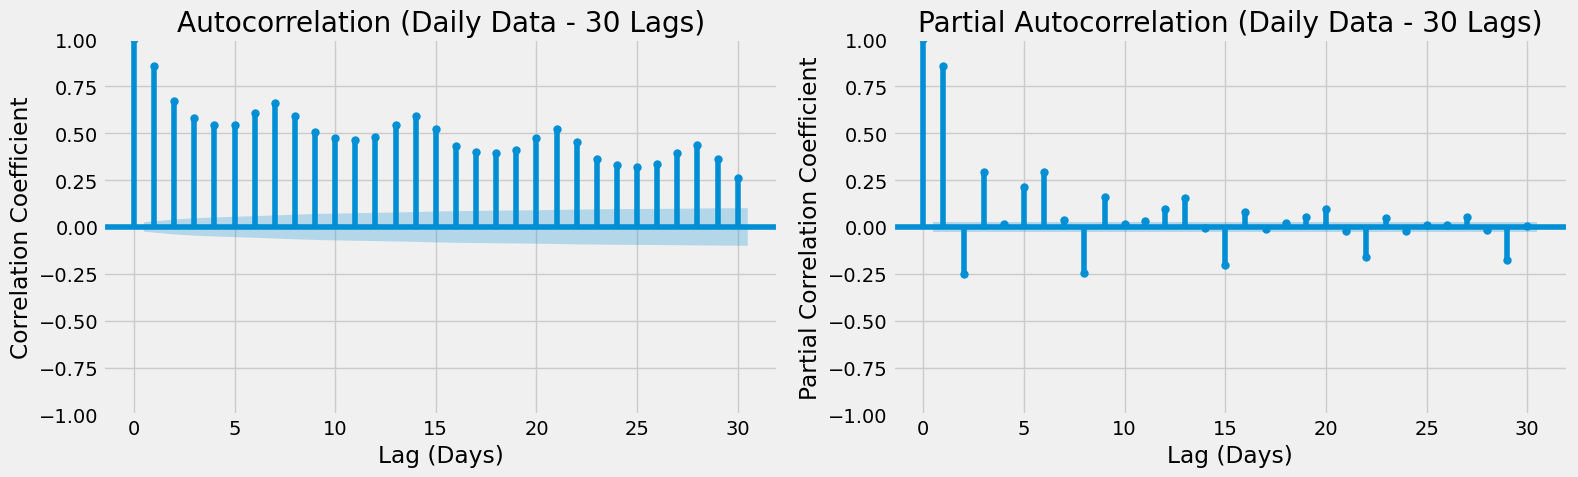

In [13]:
# Resampling the hourly data to daily frequency to reduce noise and calculation time.
# Calculates the average MW consumption for the 24 hours of each day.
df_daily = df.resample('D').mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Shows the correlation of the series with its past values (including indirect effects)
plot_acf(df_daily['PJME_MW'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation (Daily Data - 30 Lags)')
axes[0].set_xlabel('Lag (Days)')
axes[0].set_ylabel('Correlation Coefficient')

# Shows the pure, direct correlation of the series with its past values (stripping intermediate effects)
plot_pacf(df_daily['PJME_MW'].dropna(), lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (Daily Data - 30 Lags)')
axes[1].set_xlabel('Lag (Days)')
axes[1].set_ylabel('Partial Correlation Coefficient')

plt.tight_layout()
plt.show()

Conclusion:

* **ACF Conclusion:** There is a very strong weekly seasonality in the data. This is entirely expected for an electricity consumption time series: the electricity demand on a Tuesday is much more similar to the demand on the previous Tuesday than to the demand on the previous Sunday.

* **PACF Conclusion:** For the model, the two most informative lagged observations are clearly **Lag 1** (the previous day's value) and **Lag 7** (the value from the same day of the previous week).

Note:

* **d = Degree of differencing**, i.e., the number of times the time series must be differenced to become stationary.
* **p = Autoregressive (AR) component**, indicating how many previous time periods (e.g., days) the model should consider. This value is determined from the *PACF plot*.
* **q = Moving Average (MA) component**, indicating how many past forecast errors (residuals) the model should take into account. This value is determined from the *ACF plot*.

# Check for stationery

In [14]:
def run_adf_test(series, series_name):
    print(f"--- Augmented Dickey-Fuller Test on '{series_name}' ---")
    
    adf_result = adfuller(series.dropna(), autolag='AIC')
    adf_statistic = adf_result[0]
    p_value = adf_result[1]
    critical_values = adf_result[4]
    
    print(f"ADF Statistic: {adf_statistic:.4f}")
    print(f"p-value: {p_value}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"   {key}: {value:.4f}")
        
    print("-" * 40)
    if p_value <= 0.05:
        print("Conclusion: Reject the null hypothesis (H0).")
        print("The time series is STATIONARY.\n")
    else:
        print("Conclusion: Fail to reject the null hypothesis (H0).")
        print("The time series is NON-STATIONARY. Differencing is required.\n")


run_adf_test(df_daily['PJME_MW'], "Original Daily Consumption")

--- Augmented Dickey-Fuller Test on 'Original Daily Consumption' ---
ADF Statistic: -8.2610
p-value: 5.084298115214805e-13
Critical Values:
   1%: -3.4314
   5%: -2.8620
   10%: -2.5670
----------------------------------------
Conclusion: Reject the null hypothesis (H0).
The time series is STATIONARY.



In [15]:
df

,PJME_MW,Hour,DayOfWeek,Month,Year,Quarter,DayOfYear
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,1,1
2002-01-01 02:00:00,29265.0,2,1,1,2002,1,1
2002-01-01 03:00:00,28357.0,3,1,1,2002,1,1
2002-01-01 04:00:00,27899.0,4,1,1,2002,1,1
2002-01-01 05:00:00,28057.0,5,1,1,2002,1,1
...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,8,2018,3,214
2018-08-02 21:00:00,43256.0,21,3,8,2018,3,214
2018-08-02 22:00:00,41552.0,22,3,8,2018,3,214


# Time Series Split

In [16]:
X = ['Hour', 'DayOfWeek', 'Month', 'Year', 'Quarter', 'DayOfYear']
y = 'PJME_MW'

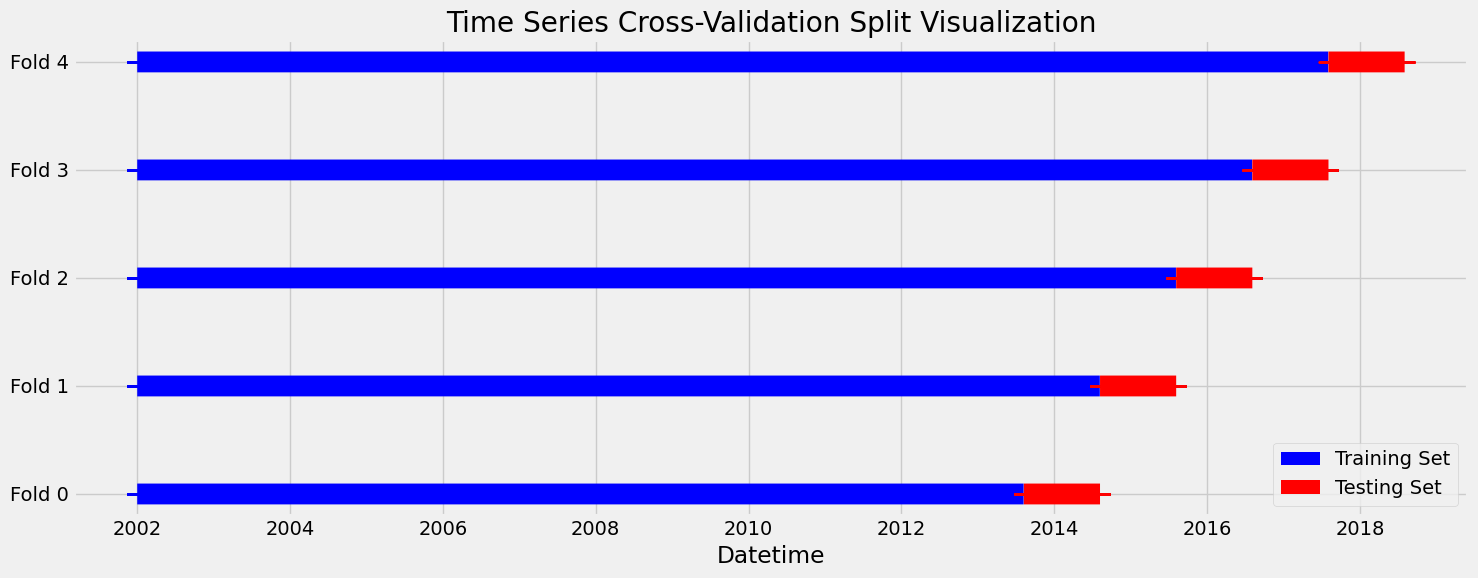

--- Cross Validation Fold Details ---
Fold 0:
  Train: 2002-01-01 to 2013-08-07 (101662 hours)
  Test:  2013-08-08 to 2014-08-08 (8736 hours)

Fold 1:
  Train: 2002-01-01 to 2014-08-07 (110398 hours)
  Test:  2014-08-08 to 2015-08-07 (8736 hours)

Fold 2:
  Train: 2002-01-01 to 2015-08-06 (119134 hours)
  Test:  2015-08-07 to 2016-08-05 (8736 hours)

Fold 3:
  Train: 2002-01-01 to 2016-08-04 (127870 hours)
  Test:  2016-08-05 to 2017-08-04 (8736 hours)

Fold 4:
  Train: 2002-01-01 to 2017-08-03 (136606 hours)
  Test:  2017-08-04 to 2018-08-03 (8736 hours)



In [17]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*364*1, gap=24)


fig, ax = plt.subplots(figsize=(15, 6))
cmap_data = plt.cm.coolwarm


for fold, (train_idx, val_idx) in enumerate(tss.split(df)):
    train_indices = df.index[train_idx]
    test_indices = df.index[val_idx]
    
    ax.plot(train_indices, [fold] * len(train_indices), 
            color='blue', marker='_', lw=15, markersize=15)
    
    ax.plot(test_indices, [fold] * len(test_indices), 
            color='red', marker='_', lw=15, markersize=15)


ax.set_yticks(np.arange(5))
ax.set_yticklabels([f'Fold {i}' for i in range(5)])
ax.set_xlabel('Datetime')
ax.set_title('Time Series Cross-Validation Split Visualization')

legend_elements = [Patch(facecolor='blue', label='Training Set'),
                   Patch(facecolor='red', label='Testing Set')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


print("--- Cross Validation Fold Details ---")
for fold, (train_idx, val_idx) in enumerate(tss.split(df)):
    train_start = df.index[train_idx.min()].strftime('%Y-%m-%d')
    train_end = df.index[train_idx.max()].strftime('%Y-%m-%d')
    test_start = df.index[val_idx.min()].strftime('%Y-%m-%d')
    test_end = df.index[val_idx.max()].strftime('%Y-%m-%d')
    
    print(f"Fold {fold}:")
    print(f"  Train: {train_start} to {train_end} ({len(train_idx)} hours)")
    print(f"  Test:  {test_start} to {test_end} ({len(val_idx)} hours)\n")

# XGBoostRegressor

In [18]:
rmse_scores = []
mae_scores = []
mape_scores = []
cv_predictions = {}

print("--- Starting XGBoost Cross-Validation Training ---")
print("Training models across 5 folds with early stopping...\n")

for fold, (train_idx, val_idx) in enumerate(tss.split(df)):
    train_fold = df.iloc[train_idx]
    test_fold = df.iloc[val_idx]
    
    X_train, y_train = train_fold[X], train_fold[y]
    X_test, y_test = test_fold[X], test_fold[y]
    
    reg = xgb.XGBRegressor(
        n_estimators=1500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    reg.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100
    )

    
    y_pred = reg.predict(X_test)

    cv_predictions[f'Fold_{fold}'] = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred
    }, index=test_fold.index)
    
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    mape_scores.append(mape)
    
    print(f"Fold {fold} Results -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")


print("\n" + "="*45)
print("--- FINAL CROSS-VALIDATION SUMMARY (XGBOOST) ---")
print("="*45)
print(f"Overall Mean RMSE: {np.mean(rmse_scores):.2f}")
print(f"Overall Mean MAE:  {np.mean(mae_scores):.2f}")
print(f"Overall Mean MAPE: {np.mean(mape_scores):.2f}%")
print("="*45)

--- Starting XGBoost Cross-Validation Training ---
Training models across 5 folds with early stopping...

[0]	validation_0-rmse:6432.29430	validation_1-rmse:6154.34383
[100]	validation_0-rmse:3102.08055	validation_1-rmse:3644.00077
[200]	validation_0-rmse:2777.86406	validation_1-rmse:3852.73125
[300]	validation_0-rmse:2617.60305	validation_1-rmse:4166.73661
[400]	validation_0-rmse:2518.63723	validation_1-rmse:4394.55876
[500]	validation_0-rmse:2426.00282	validation_1-rmse:4577.86661
[600]	validation_0-rmse:2353.42031	validation_1-rmse:4722.65214
[700]	validation_0-rmse:2291.47162	validation_1-rmse:4802.63254
[800]	validation_0-rmse:2236.38270	validation_1-rmse:4903.87011
[900]	validation_0-rmse:2180.89973	validation_1-rmse:4940.55643
[1000]	validation_0-rmse:2128.90761	validation_1-rmse:5004.63809
[1100]	validation_0-rmse:2091.03571	validation_1-rmse:5043.58630
[1200]	validation_0-rmse:2059.63999	validation_1-rmse:5079.63058
[1300]	validation_0-rmse:2024.26018	validation_1-rmse:5102.43

# Prophet

In [19]:
print("--- Starting Prophet Model Training ---")

# Prophet requires specific column names: 'ds' for datetimes, 'y' for the target value
train_prophet = df.iloc[train_idx].reset_index()[['Datetime', 'PJME_MW']]
train_prophet = train_prophet.rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})

test_prophet = df.iloc[val_idx].reset_index()[['Datetime', 'PJME_MW']]
test_prophet = test_prophet.rename(columns={'Datetime': 'ds', 'PJME_MW': 'y'})


m = Prophet(yearly_seasonality=True, daily_seasonality=True)
m.fit(train_prophet)

future = m.make_future_dataframe(periods=len(test_prophet), freq='H')
forecast = m.predict(future)

predictions = forecast['yhat'].tail(len(test_prophet))

rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], predictions))
mae_prophet = mean_absolute_error(test_prophet['y'], predictions)
mape_prophet = mean_absolute_percentage_error(test_prophet['y'], predictions) * 100

print("\n" + "="*45)
print("--- PROPHET RESULTS (Single Fold) ---")
print("="*45)
print(f"RMSE: {rmse_prophet:.2f}")
print(f"MAE:  {mae_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")
print("="*45)

--- Starting Prophet Model Training ---


09:35:10 - cmdstanpy - INFO - Chain [1] start processing
09:36:43 - cmdstanpy - INFO - Chain [1] done processing



--- PROPHET RESULTS (Single Fold) ---
RMSE: 4497.46
MAE:  3450.98
MAPE: 10.96%


> While XGBoost is computationally light and was evaluated using a full 5-fold TimeSeriesSplit Cross-Validation, Facebook Prophet is mathematically heavy on high-frequency hourly datasets (145k+ rows). To keep computation sustainable while ensuring a fair head-to-head comparison, Prophet was evaluated on the final and largest fold, directly benchmarking it against XGBoost’s Fold 4 performance.

# Holt-Winters

In [20]:
print("--- Starting Classical Statistical Models Training ---")
print("Evaluating on Fold 4 to match XGBoost and Prophet benchmarks...\n")

train_fold = df.iloc[train_idx]
test_fold = df.iloc[val_idx]

print("Training Holt-Winters Model...")
# seasonal_periods=24 captures the daily cycle in hourly data
hw_model = ExponentialSmoothing(
    train_fold['PJME_MW'], 
    seasonal_periods=24, 
    trend='add', 
    seasonal='add', 
    initialization_method="estimated"
).fit()


hw_predictions = hw_model.forecast(len(test_fold))
hw_rmse = np.sqrt(mean_squared_error(test_fold['PJME_MW'], hw_predictions))
hw_mae = mean_absolute_error(test_fold['PJME_MW'], hw_predictions)
hw_mape = mean_absolute_percentage_error(test_fold['PJME_MW'], hw_predictions) * 100

print(f"Holt-Winters Results -> RMSE: {hw_rmse:.2f} | MAE: {hw_mae:.2f} | MAPE: {hw_mape:.2f}%\n")

--- Starting Classical Statistical Models Training ---
Evaluating on Fold 4 to match XGBoost and Prophet benchmarks...

Training Holt-Winters Model...
Holt-Winters Results -> RMSE: 7659.31 | MAE: 6082.39 | MAPE: 20.29%



# SARIMA

In [21]:
print("Training SARIMA Model...")
print("Note: Using the last 3 months of training data to prevent memory overload.")

# 3 months = approx 90 days * 24 hours = 2160 hours
# We slice the training data to only include the most recent history
train_sarima = train_fold['PJME_MW'].iloc[-2160:]


sarima_model = SARIMAX(
    train_sarima,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_predictions = sarima_model.forecast(len(test_fold))

sarima_rmse = np.sqrt(mean_squared_error(test_fold['PJME_MW'], sarima_predictions))
sarima_mae = mean_absolute_error(test_fold['PJME_MW'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_fold['PJME_MW'], sarima_predictions) * 100

print(f"SARIMA Results -> RMSE: {sarima_rmse:.2f} | MAE: {sarima_mae:.2f} | MAPE: {sarima_mape:.2f}%\n")

Training SARIMA Model...
Note: Using the last 3 months of training data to prevent memory overload.
SARIMA Results -> RMSE: 27244.88 | MAE: 25366.09 | MAPE: 80.90%



# Models Comparison

In [22]:
print("="*45)
print("--- ALL MODELS PERFORMANCE SUMMARY (FOLD 4) ---")
print("="*45)
print(f"XGBoost       -> MAPE: 9.59%  | RMSE: 4234.24") 
print(f"Prophet       -> MAPE: 10.96% | RMSE: 4497.46") 
print(f"Holt-Winters  -> MAPE: {hw_mape:.2f}% | RMSE: {hw_rmse:.2f}")
print(f"SARIMA        -> MAPE: {sarima_mape:.2f}% | RMSE: {sarima_rmse:.2f}")
print("="*45)

--- ALL MODELS PERFORMANCE SUMMARY (FOLD 4) ---
XGBoost       -> MAPE: 9.59%  | RMSE: 4234.24
Prophet       -> MAPE: 10.96% | RMSE: 4497.46
Holt-Winters  -> MAPE: 20.29% | RMSE: 7659.31
SARIMA        -> MAPE: 80.90% | RMSE: 27244.88


**MAPE (Mean Absolute Percentage Error):** 
This means that, on average, the model's predictions differ from the actual electricity consumption by 9.59%. An error below (or very close to) 10% is considered a good result for such a long forecasting horizon, especially when the model relies only on historical time-series information (i.e., without using external variables such as weather data).

**MAE (Mean Absolute Error):** 
On average, the model's hourly predictions differ from the actual electricity consumption by 3,178.40 megawatts (MW).

**RMSE (Root Mean Squared Error):**
This metric penalizes larger prediction errors more heavily. Since the RMSE is higher than the MAE, it indicates that the model has greater difficulty accurately predicting peak electricity demand (extreme spikes). For the XGBoost model, the RMSE was 4,234.24 MW.

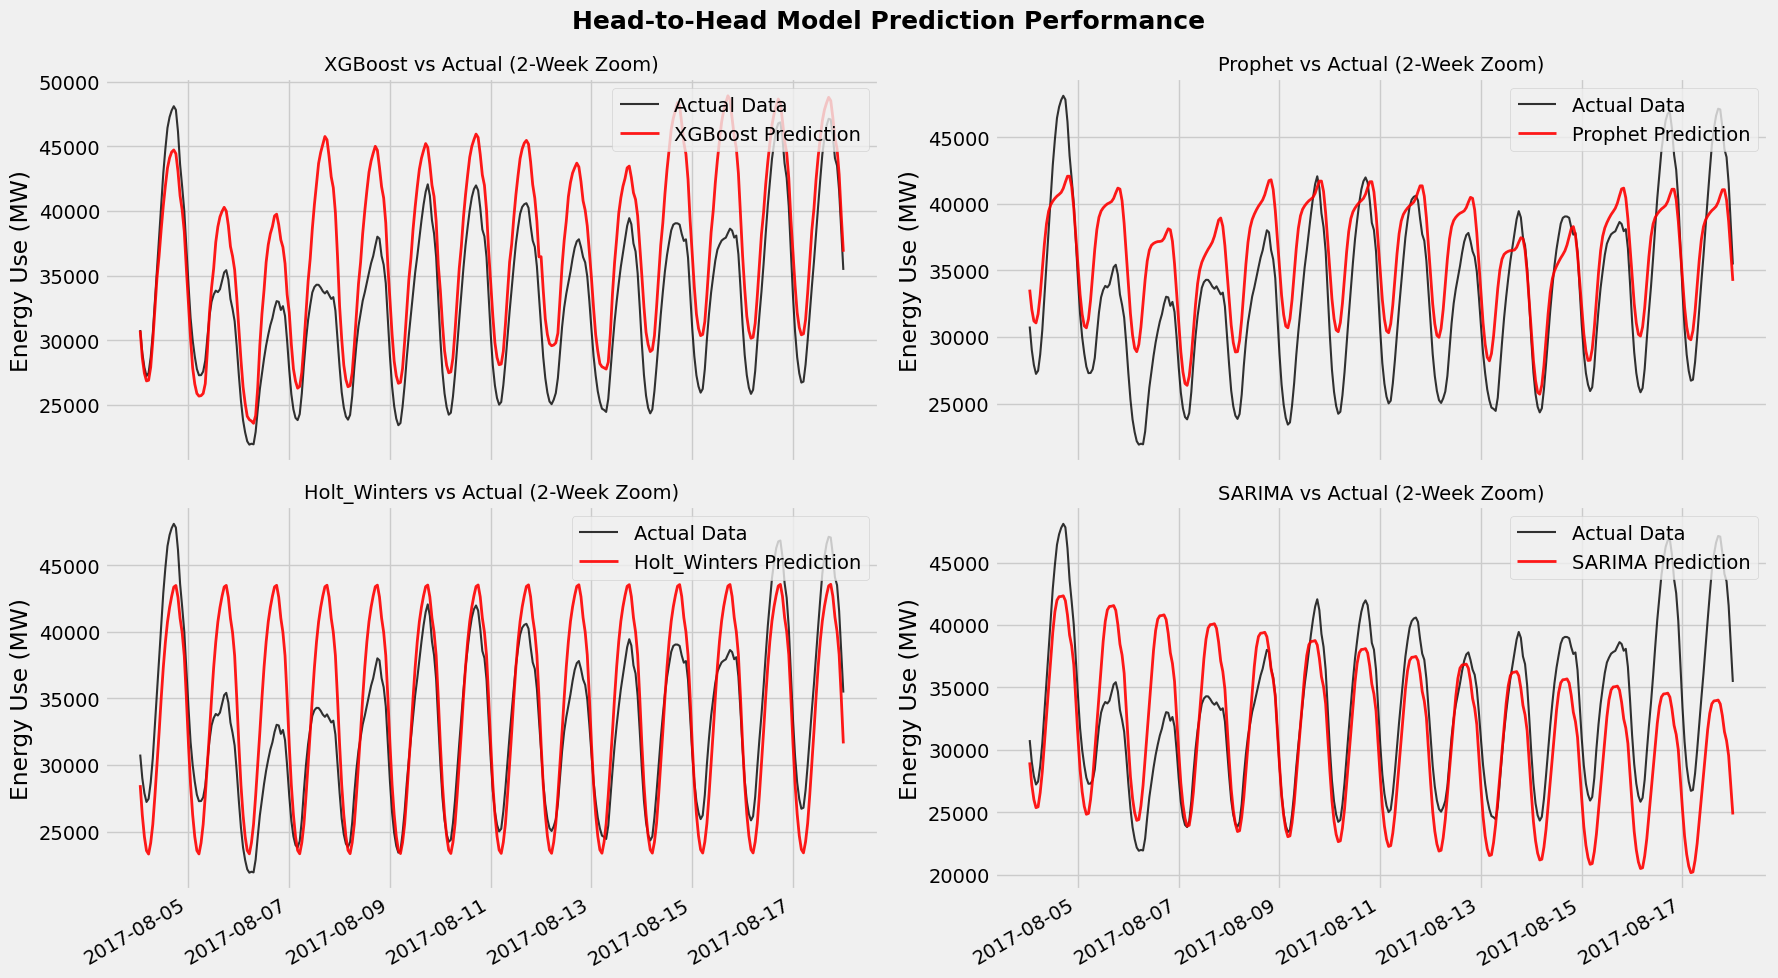

In [24]:
# Aligning all predictions into a single dataframe for easy plotting
test_dates = df.iloc[val_idx].index

results_plot_df = pd.DataFrame(index=test_dates)
results_plot_df['Actual'] = df.iloc[val_idx]['PJME_MW'].values
results_plot_df['XGBoost'] = cv_predictions['Fold_4']['Predicted'].values

results_plot_df['Prophet'] = predictions.values  # From the Prophet cell
results_plot_df['Holt_Winters'] = hw_predictions.values
results_plot_df['SARIMA'] = sarima_predictions.values

# Zoom in on a 2-week window to make the hourly lines clearly visible
zoom_slice = results_plot_df.iloc[:336]


fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
axes = axes.flatten()

models = ['XGBoost', 'Prophet', 'Holt_Winters', 'SARIMA']

for i, model_name in enumerate(models):
    axes[i].plot(zoom_slice.index, zoom_slice['Actual'], 
                 color='black', label='Actual Data', alpha=0.8, lw=1.5)
    
    axes[i].plot(zoom_slice.index, zoom_slice[model_name], 
                 color='red', label=f'{model_name} Prediction', alpha=0.9, lw=2)
   
    axes[i].set_title(f'{model_name} vs Actual (2-Week Zoom)', fontsize=14)
    axes[i].legend(loc='upper right')
    axes[i].set_ylabel('Energy Use (MW)')
    plt.setp(axes[i].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('Head-to-Head Model Prediction Performance', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Based on the statistical metrics and the 2-week visual zoom of our test set (Fold 4), we can draw several key insights regarding how different algorithms handle high-frequency, multi-seasonal time series data:
- **XGBoost** proved to be the most effective model for this dataset. The visual overlay shows that it successfully learned both the intra-day peaks and the intra-week valleys (notice the accurate, deeper dips during the weekends of Aug 5-6 and Aug 12-13). By leveraging explicit temporal features (`Hour`, `DayOfWeek`, etc.), it dynamically adapts to the varying amplitudes of energy consumption without succumbing to rigid patterns.
- **Facebook Prophet** performed exceptionally well, acting as a strong runner-up. The chart demonstrates that it effortlessly captured the dual seasonality (daily and weekly cycles) natively, without requiring the manual feature engineering that XGBoost needed. While its predictions are slightly smoother and it occasionally over-predicts or misses the sharpest extreme peaks, it provides a highly reliable, mathematically elegant forecast.
- The visual analysis perfectly illustrates the limitations of traditional statistical models on long-horizon, high-frequency data. Both **Holt-Winters** and **SARIMA** fall into the trap of rigid seasonality. Because they were primarily configured for a 24-hour cycle, they repeat the exact same daily wave indefinitely. They completely fail to account for the weekly macro-patterns (the significant drop in energy demand on weekends), resulting in massive over-predictions on Saturdays and Sundays.